# Tile Download Verification

Restricted to the stratified 10% sample (41 FIDs) across the 3 foundation-model tile sets:
- **CROMA** — 120×120 px, products: `s2_l2a`, `s1_grd`
- **TerraFM** — 224×224 px, products: `s2_l2a`, `s1_rtc`
- **Clay** — 256×256 px, products: `s2_l2a`, `s1_rtc`

Checks:
1. How many tiles were downloaded per model × product × window
2. Which sample FIDs are missing per set, version info from v1/v2/v3 CSVs
3. Tile integrity: dimensions, band count, file size
4. Missing image IDs per FID (expected from CSVs vs on disk)
5. Disk usage per model × product
6. Delete the duplicates adn the specific noisy image


In [1]:
import os
import csv
import json
import glob
import random
from pathlib import Path
from collections import defaultdict

import rasterio
import numpy as np
import matplotlib.pyplot as plt

# ── Load shapefile (WGS 84) and reproject to UTM 20S (SIRGAS 2000) ──
SCRIPT_DIR = os.path.dirname(os.path.abspath("__file__"))
SHP_DIR = os.path.join(SCRIPT_DIR, "data_shp")
if os.path.exists(os.path.expanduser("~/thesis_scripts/data_shp")):
    SHP_DIR = os.path.expanduser("~/thesis_scripts/data_shp")
CSV_DIR = os.path.join(SCRIPT_DIR, "data_csv")

# ── Load 10% stratified sample (41 FIDs) ──
SAMPLE_PATH = os.path.join(CSV_DIR, "sample_10pct_stratified.txt")
with open(SAMPLE_PATH) as f:
    SAMPLE_FIDS = {line.strip() for line in f if line.strip()}
print(f"Sample: {len(SAMPLE_FIDS)} FIDs from {SAMPLE_PATH}")

# ── Base directory for tile sets ──
if os.path.exists(os.path.expanduser("~/thesis_tiles_120px")):
    BASE = os.path.expanduser("~")
else:
    BASE = "/Users/angelicamariamorenorojas/Desktop/Master/thesis"

# ── 3 tile sets, one per foundation model ──
TILE_SETS = {
    "CROMA":   {"dir": os.path.join(BASE, "thesis_tiles_120px"), "size": 120, "products": ["s2_l2a", "s1_grd"]},
    "TerraFM": {"dir": os.path.join(BASE, "thesis_tiles_224px"), "size": 224, "products": ["s2_l2a", "s1_rtc"]},
    "Clay":    {"dir": os.path.join(BASE, "thesis_tiles_256px"), "size": 256, "products": ["s2_l2a", "s1_rtc"]},
}

WINDOWS = ["evt", "bef", "aft"]

EXPECTED_BANDS = {
    "s2_l2a": 12,
    "s1_grd": 2,
    "s1_rtc": 2,
}

# All products across the 3 sets (for iteration)
ALL_PRODUCTS = sorted({p for s in TILE_SETS.values() for p in s["products"]})

print(f"CSV directory: {CSV_DIR}")
print(f"Sample: {len(SAMPLE_FIDS)} FIDs (stratified 10%)")
print()
print(f"{'Model':<10} {'Tile dir':<45} {'Size':>6} {'Products'}")
print("-" * 90)
for model, cfg in TILE_SETS.items():
    exists = "✓" if os.path.exists(cfg["dir"]) else "✗ MISSING"
    print(f"{model:<10} {cfg['dir']:<45} {cfg['size']:>4}² {'+'.join(cfg['products'])}  {exists}")


Sample: 41 FIDs from /share/castor/home/e2406749/tropical_forest_disturbance/data_csv/sample_10pct_stratified.txt
CSV directory: /share/castor/home/e2406749/tropical_forest_disturbance/data_csv
Sample: 41 FIDs (stratified 10%)

Model      Tile dir                                        Size Products
------------------------------------------------------------------------------------------
CROMA      /share/home/e2406749/thesis_tiles_120px        120² s2_l2a+s1_grd  ✓
TerraFM    /share/home/e2406749/thesis_tiles_224px        224² s2_l2a+s1_rtc  ✗ MISSING
Clay       /share/home/e2406749/thesis_tiles_256px        256² s2_l2a+s1_rtc  ✗ MISSING


## 1. Scan downloaded tiles

In [2]:
# Count .tif files per (model, product, window). Restrict to sample FIDs.
# Structure: downloaded[model][product][window] = [paths]
downloaded = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        product_dir = os.path.join(cfg["dir"], product)
        if not os.path.exists(product_dir):
            continue
        for tif in glob.glob(os.path.join(product_dir, "fid_*", "*", "*", "*.tif")):
            parts = Path(tif).parts
            fid_idx = next(i for i, p in enumerate(parts) if p.startswith("fid_"))
            fid = parts[fid_idx].replace("fid_", "")
            if fid not in SAMPLE_FIDS:
                continue  # ignore non-sample tiles (e.g. leftover from old runs)
            window = parts[fid_idx + 1]
            downloaded[model][product][window].append(tif)

# Summary table: model × product rows, window columns
print(f"{'Model':<8} {'Product':<10} {'evt':>8} {'bef':>8} {'aft':>8} {'TOTAL':>8}")
print("-" * 56)
grand_total = 0
for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        counts = {w: len(downloaded[model][product][w]) for w in WINDOWS}
        total = sum(counts.values())
        grand_total += total
        print(f"{model:<8} {product:<10} {counts['evt']:>8} {counts['bef']:>8} {counts['aft']:>8} {total:>8}")
print("-" * 56)
print(f"{'TOTAL':<19} {'':>8} {'':>8} {'':>8} {grand_total:>8}")


Model    Product         evt      bef      aft    TOTAL
--------------------------------------------------------
CROMA    s2_l2a          120     1051      203     1374
CROMA    s1_grd          136     1414      147     1697
TerraFM  s2_l2a            0        0        0        0
TerraFM  s1_rtc            0        0        0        0
Clay     s2_l2a            0        0        0        0
Clay     s1_rtc            0        0        0        0
--------------------------------------------------------
TOTAL                                              3071


## 2. Expected vs Downloaded (from CSVs)

if ANY filter version found an image useful, we download it. The expected table shows the total unique images across all versions, which is exactly what the pipeline should have downloaded.

In [3]:
# Parse v1/v2/v3 CSVs. For each (fid, sensor, window, image_id) track which
# filter versions listed that image. Restrict to sample FIDs only.
IMAGE_ID_COLUMNS = {
    ("s2", "evt"): "evtIdsS2", ("s2", "bef"): "befIdsS2", ("s2", "aft"): "aftIdsS2",
    ("s1", "evt"): "evtIdsS1", ("s1", "bef"): "befIdsS1", ("s1", "aft"): "aftIdsS1",
}

CSV_FILES = ["v1_images_s2_s1.csv", "v2_images_s2_s1.csv", "v3_images_s2_s1.csv"]

# expected[fid][(sensor, window)] = {image_id: set(versions that include it)}
expected = defaultdict(lambda: defaultdict(lambda: defaultdict(set)))

for csv_name in CSV_FILES:
    version = csv_name.split("_")[0]  # v1, v2, v3
    csv_path = os.path.join(CSV_DIR, csv_name)
    if not os.path.exists(csv_path):
        print(f"WARNING: {csv_path} not found")
        continue
    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            fid = row["fid"].strip()
            if fid not in SAMPLE_FIDS:
                continue
            for (sensor, window), col in IMAGE_ID_COLUMNS.items():
                raw = row.get(col, "").strip()
                if not raw:
                    continue
                ids = [x.strip() for x in raw.split(",") if x.strip()]
                for img_id in ids:
                    expected[fid][(sensor, window)][img_id].add(version)

# Count unique (fid, window, image_id) per sensor across the sample
expected_counts = defaultdict(lambda: defaultdict(int))
version_only_counts = defaultdict(int)  # images appearing in only 1 version

for fid, sw_dict in expected.items():
    for (sensor, window), id_versions in sw_dict.items():
        expected_counts[sensor][window] += len(id_versions)
        for img_id, versions in id_versions.items():
            if len(versions) == 1:
                version_only_counts[list(versions)[0]] += 1

print(f"Sample FIDs with data in CSVs: {len(expected)} / {len(SAMPLE_FIDS)}")
print()
print(f"Expected unique images per sensor (sample only):")
print(f"{'Sensor':<8} {'evt':>8} {'bef':>8} {'aft':>8} {'TOTAL':>8}")
print("-" * 44)
for sensor in ["s2", "s1"]:
    row = {w: expected_counts[sensor][w] for w in WINDOWS}
    total = sum(row.values())
    print(f"{sensor:<8} {row['evt']:>8} {row['bef']:>8} {row['aft']:>8} {total:>8}")

print("\nImages appearing in ONLY one filter version (cloud filter differences):")
for v in ["v1", "v2", "v3"]:
    print(f"  Only in {v}: {version_only_counts[v]}")


Sample FIDs with data in CSVs: 41 / 41

Expected unique images per sensor (sample only):
Sensor        evt      bef      aft    TOTAL
--------------------------------------------
s2             56      423       88      567
s1             53      535       57      645

Images appearing in ONLY one filter version (cloud filter differences):
  Only in v1: 77
  Only in v2: 0
  Only in v3: 0


In [7]:
per_version = defaultdict(set)
for fid, sw_dict in expected.items():                                                     
    for (sensor, window), id_versions in sw_dict.items():                                 
        for img_id, versions in id_versions.items():                                      
            for v in versions:                                                            
                per_version[v].add((fid, sensor, window, img_id))                         
                                                                                        
print("Total images per version (sample only):")
for v in ["v1", "v2", "v3"]:                                                              
    print(f"  {v}: {len(per_version[v])} images")         
                                                                                        
print("\nOverlap matrix (intersection sizes):")
print(f"{'':>4} {'v1':>6} {'v2':>6} {'v3':>6}")                                           
for a in ["v1", "v2", "v3"]:                              
    row = f"{a:>4}"                                                                       
    for b in ["v1", "v2", "v3"]:
        row += f" {len(per_version[a] & per_version[b]):>6}"                              
    print(row)                                                                            

print("\nExclusive (in exactly one version):")                                            
only_v1 = len(per_version["v1"] - per_version["v2"] - per_version["v3"])
only_v2 = len(per_version["v2"] - per_version["v1"] - per_version["v3"])                  
only_v3 = len(per_version["v3"] - per_version["v1"] - per_version["v2"])
print(f"  Only v1 (not v2, not v3): {only_v1}")                                           
print(f"  Only v2 (not v1, not v3): {only_v2}")           
print(f"  Only v3 (not v1, not v2): {only_v3}")                                           
                                                        
print("\nNested check:")                                                                  
print(f"  v2 subset of v1?  {per_version['v2'].issubset(per_version['v1'])}")
print(f"  v3 subset of v2?  {per_version['v3'].issubset(per_version['v2'])}")             
print(f"  v3 subset of v1?  {per_version['v3'].issubset(per_version['v1'])}") 

Total images per version (sample only):
  v1: 1211 images
  v2: 1135 images
  v3: 1094 images

Overlap matrix (intersection sizes):
         v1     v2     v3
  v1   1211   1134   1093
  v2   1134   1135   1094
  v3   1093   1094   1094

Exclusive (in exactly one version):
  Only v1 (not v2, not v3): 77
  Only v2 (not v1, not v3): 0
  Only v3 (not v1, not v2): 0

Nested check:
  v2 subset of v1?  False
  v3 subset of v2?  True
  v3 subset of v1?  False


In [4]:
import pandas as pd                                                                       
import geopandas as gpd                
                                                                                        
# Load shapefile to compute polygon pixel count
shp_path = os.path.join(SHP_DIR, "label_polygons.shp")                                    
_gdf = gpd.read_file(shp_path)                                                            
_gdf["fid"] = _gdf["fid"].astype(int).astype(str)                                         
_gdf_utm = _gdf.to_crs("EPSG:31980")                                                      
_gdf_utm["area_px"] = (_gdf_utm.geometry.area / 10).round().astype(int)                   
poly_pixels = dict(zip(_gdf["fid"], _gdf_utm["area_px"]))                                 
                                                                                        
CSV_FILES = ["v1_images_s2_s1.csv", "v2_images_s2_s1.csv", "v3_images_s2_s1.csv"]         
COLS_TO_SHOW = ["fid", "VIEW_DATE", "CLASSNAME", "MUNICIPALI", "UF",                      
                "area_km2", "polygon_px",                                                 
                "evtFndS2", "befFndS2", "aftFndS2",                                       
                "evtFndS1", "befFndS1", "aftFndS1"]
                                                                                        
for csv_name in CSV_FILES:                                                                
    csv_path = os.path.join(CSV_DIR, csv_name)
    if not os.path.exists(csv_path):                                                      
        print(f"WARNING: {csv_path} not found")           
        continue                                                                          
    df = pd.read_csv(csv_path)
    df["fid"] = df["fid"].astype(str)                                                     
    df["polygon_px"] = df["fid"].map(poly_pixels)         
    df_sample = df[df["fid"].isin(SAMPLE_FIDS)]                                           
    cols = [c for c in COLS_TO_SHOW if c in df_sample.columns]
    print(f"\n========== {csv_name} ({len(df_sample)} rows for sample FIDs) ==========")  
    display(df_sample[cols].sort_values("fid", key=lambda s:
s.astype(int)).reset_index(drop=True))  


========== v1_images_s2_s1.csv (41 rows for sample FIDs) ==========


,fid,VIEW_DATE,CLASSNAME,MUNICIPALI,UF,area_km2,polygon_px,evtFndS2,befFndS2,aftFndS2,evtFndS1,befFndS1,aftFndS1
0,3,1695970800000,Disorderly Selective logging,Itapua do Oeste,RO,0.463429,46115,3,20,1,1,19,2
1,13,1696143600000,Fire scar,Porto Velho,RO,0.069240,6890,0,22,1,1,19,2
2,23,1697612400000,Degradation,Cujubim,RO,0.089723,8929,1,22,1,2,20,1
3,27,1697612400000,Fire scar,Cujubim,RO,0.098038,9756,1,22,1,2,20,1
4,29,1697698800000,Degradation,Itapua do Oeste,RO,1.641504,163340,0,23,1,2,20,1
5,30,1697698800000,Clear-cut bare soil,Porto Velho,RO,0.104265,10376,1,23,0,4,40,2
6,71,1694242800000,Fire scar,Porto Velho,RO,0.106659,10613,2,17,2,1,18,1
7,92,1678863600000,Clear-cut bare soil,Candeias do Jamari,RO,0.258260,25698,0,2,2,1,4,0
8,93,1678863600000,Clear-cut bare soil,Porto Velho,RO,0.417235,41518,0,1,0,1,4,0
9,101,1684047600000,Clear-cut bare soil,Cujubim,RO,0.078879,7849,2,4,3,1,8,1



========== v2_images_s2_s1.csv (41 rows for sample FIDs) ==========


,fid,VIEW_DATE,CLASSNAME,MUNICIPALI,UF,area_km2,polygon_px,evtFndS2,befFndS2,aftFndS2,evtFndS1,befFndS1,aftFndS1
0,3,1695970800000,Disorderly Selective logging,Itapua do Oeste,RO,0.463429,46115,3,17,0,1,19,2
1,13,1696143600000,Fire scar,Porto Velho,RO,0.069240,6890,0,18,0,1,19,2
2,23,1697612400000,Degradation,Cujubim,RO,0.089723,8929,1,20,1,2,20,1
3,27,1697612400000,Fire scar,Cujubim,RO,0.098038,9756,0,20,1,2,20,1
4,29,1697698800000,Degradation,Itapua do Oeste,RO,1.641504,163340,0,21,1,2,20,1
5,30,1697698800000,Clear-cut bare soil,Porto Velho,RO,0.104265,10376,1,20,0,4,40,2
6,71,1694242800000,Fire scar,Porto Velho,RO,0.106659,10613,1,13,2,1,18,1
7,92,1678863600000,Clear-cut bare soil,Candeias do Jamari,RO,0.258260,25698,0,0,0,1,4,0
8,93,1678863600000,Clear-cut bare soil,Porto Velho,RO,0.417235,41518,0,0,0,1,4,0
9,101,1684047600000,Clear-cut bare soil,Cujubim,RO,0.078879,7849,2,2,3,1,8,1



========== v3_images_s2_s1.csv (41 rows for sample FIDs) ==========


,fid,VIEW_DATE,CLASSNAME,MUNICIPALI,UF,area_km2,polygon_px,evtFndS2,befFndS2,aftFndS2,evtFndS1,befFndS1,aftFndS1
0,3,1695970800000,Disorderly Selective logging,Itapua do Oeste,RO,0.463429,46115,3,15,0,1,19,2
1,13,1696143600000,Fire scar,Porto Velho,RO,0.069240,6890,0,16,0,1,19,2
2,23,1697612400000,Degradation,Cujubim,RO,0.089723,8929,1,20,1,2,20,1
3,27,1697612400000,Fire scar,Cujubim,RO,0.098038,9756,0,19,1,2,20,1
4,29,1697698800000,Degradation,Itapua do Oeste,RO,1.641504,163340,0,19,1,2,20,1
5,30,1697698800000,Clear-cut bare soil,Porto Velho,RO,0.104265,10376,1,19,0,4,40,2
6,71,1694242800000,Fire scar,Porto Velho,RO,0.106659,10613,1,8,2,1,18,1
7,92,1678863600000,Clear-cut bare soil,Candeias do Jamari,RO,0.258260,25698,0,0,0,1,4,0
8,93,1678863600000,Clear-cut bare soil,Porto Velho,RO,0.417235,41518,0,0,0,1,4,0
9,101,1684047600000,Clear-cut bare soil,Cujubim,RO,0.078879,7849,2,1,2,1,8,1


In [9]:
# For each tile set, which sample FIDs actually appear on disk
print(f"{'Model':<10} {'Expected':>10} {'Downloaded':>12} {'Missing':>10} {'Extra':>8}")
print("-" * 54)
for model, cfg in TILE_SETS.items():
    downloaded_fids = set()
    for product in cfg["products"]:
        product_dir = os.path.join(cfg["dir"], product)
        if not os.path.exists(product_dir):
            continue
        for d in os.listdir(product_dir):
            if d.startswith("fid_"):
                fid = d.replace("fid_", "")
                if fid in SAMPLE_FIDS:
                    downloaded_fids.add(fid)
    missing = SAMPLE_FIDS - downloaded_fids
    # "extra" would be non-sample FIDs on disk that leaked in (e.g. older runs)
    all_on_disk = set()
    for product in cfg["products"]:
        product_dir = os.path.join(cfg["dir"], product)
        if os.path.exists(product_dir):
            for d in os.listdir(product_dir):
                if d.startswith("fid_"):
                    all_on_disk.add(d.replace("fid_", ""))
    extra = all_on_disk - SAMPLE_FIDS
    print(f"{model:<10} {len(SAMPLE_FIDS):>10} {len(downloaded_fids):>12} {len(missing):>10} {len(extra):>8}")
    if missing:
        print(f"           Missing FIDs: {sorted(missing, key=int)}")
    if extra:
        print(f"           Extra FIDs (not in sample): {sorted(extra, key=int)}")


Model        Expected   Downloaded    Missing    Extra
------------------------------------------------------
CROMA              41           41          0      348
           Extra FIDs (not in sample): ['1', '2', '4', '5', '6', '7', '8', '9', '10', '11', '12', '14', '15', '16', '17', '18', '19', '20', '21', '22', '24', '25', '26', '28', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '94', '95', '96', '97', '98', '99', '100', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '114', '117', '118', '119', '120', '121', '122', '123', '124', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143

## 3. Tile integrity check (dimensions, bands, file size)

In [5]:
# Check a sample of tiles per (model, product) for dimensions, bands, corruption
random.seed(42)
MAX_CHECK = 2000

issues = []
for model, cfg in TILE_SETS.items():
    expected_size = cfg["size"]
    for product in cfg["products"]:
        all_tiles = []
        for w in WINDOWS:
            all_tiles.extend(downloaded[model][product][w])
        if not all_tiles:
            print(f"{model} / {product}: no tiles found, skipping")
            continue

        sample = random.sample(all_tiles, min(MAX_CHECK, len(all_tiles)))
        ok = bad_size = bad_bands = corrupted = zero_size = 0
        sizes_mb = []

        for tif_path in sample:
            fsize = os.path.getsize(tif_path)
            sizes_mb.append(fsize / 1e6)
            if fsize == 0:
                zero_size += 1
                issues.append((model, product, tif_path, "empty file"))
                continue
            try:
                with rasterio.open(tif_path) as src:
                    h, w = src.height, src.width
                    bands = src.count
                    if h != expected_size or w != expected_size:
                        bad_size += 1
                        issues.append((model, product, tif_path, f"size {w}x{h} (expected {expected_size}²)"))
                    elif bands != EXPECTED_BANDS[product]:
                        bad_bands += 1
                        issues.append((model, product, tif_path, f"{bands} bands (expected {EXPECTED_BANDS[product]})"))
                    else:
                        ok += 1
            except Exception as e:
                corrupted += 1
                issues.append((model, product, tif_path, f"corrupted: {e}"))

        print(f"\n{model} / {product} @ {expected_size}² (checked {len(sample)} / {len(all_tiles)}):")
        print(f"  OK: {ok}   Bad size: {bad_size}   Bad bands: {bad_bands}   Corrupted: {corrupted}   Empty: {zero_size}")
        print(f"  File size: {np.mean(sizes_mb):.2f} MB avg, {np.min(sizes_mb):.2f}-{np.max(sizes_mb):.2f} MB range")



CROMA / s2_l2a @ 120² (checked 1374 / 1374):
  OK: 1374   Bad size: 0   Bad bands: 0   Corrupted: 0   Empty: 0
  File size: 0.17 MB avg, 0.16-0.18 MB range

CROMA / s1_grd @ 120² (checked 1697 / 1697):
  OK: 1697   Bad size: 0   Bad bands: 0   Corrupted: 0   Empty: 0
  File size: 0.21 MB avg, 0.00-0.22 MB range
TerraFM / s2_l2a: no tiles found, skipping
TerraFM / s1_rtc: no tiles found, skipping
Clay / s2_l2a: no tiles found, skipping
Clay / s1_rtc: no tiles found, skipping


In [6]:
if issues:
    print(f"ISSUES FOUND: {len(issues)}\n")
    for model, product, path, msg in issues[:30]:
        short_path = "/".join(Path(path).parts[-5:])
        print(f"  [{model}/{product}] {short_path}: {msg}")
    if len(issues) > 30:
        print(f"  ... and {len(issues) - 30} more")
else:
    print("No issues found - all checked tiles are valid!")


No issues found - all checked tiles are valid!


## 4. Missing images per FID (downloaded FIDs only)

In [7]:
# Per tile set: expected image IDs (from CSVs) vs what's on disk
SENSOR_TO_PRODUCT_FOR_SET = {
    # For each model, which product answers which sensor
    "CROMA":   {"s2": "s2_l2a", "s1": "s1_grd"},
    "TerraFM": {"s2": "s2_l2a", "s1": "s1_rtc"},  # s1 ids from CSV are GRD, reused for RTC
    "Clay":    {"s2": "s2_l2a", "s1": "s1_rtc"},
}

print(f"{'Model':<10} {'Product':<10} {'Expected':>10} {'Missing':>8} {'Complete %':>12}")
print("-" * 56)
for model, cfg in TILE_SETS.items():
    # Build on_disk set: (product, fid, window, image_id)
    on_disk = set()
    for product in cfg["products"]:
        for w in WINDOWS:
            for tif_path in downloaded[model][product][w]:
                parts = Path(tif_path).parts
                fid_idx = next(i for i, p in enumerate(parts) if p.startswith("fid_"))
                fid = parts[fid_idx].replace("fid_", "")
                image_id = parts[fid_idx + 2]
                on_disk.add((product, fid, w, image_id))

    for product in cfg["products"]:
        # Find which sensor this product serves
        sensor = "s2" if product.startswith("s2") else "s1"
        exp = 0
        mis = 0
        for fid, sw_dict in expected.items():
            for (s, w), id_versions in sw_dict.items():
                if s != sensor:
                    continue
                for img_id in id_versions:
                    safe_id = img_id.replace("/", "_")
                    exp += 1
                    if (product, fid, w, safe_id) not in on_disk:
                        mis += 1
        pct = ((exp - mis) / exp * 100) if exp > 0 else 0
        print(f"{model:<10} {product:<10} {exp:>10} {mis:>8} {pct:>11.1f}%")


Model      Product      Expected  Missing   Complete %
--------------------------------------------------------
CROMA      s2_l2a            567       34        94.0%
CROMA      s1_grd            645        0       100.0%
TerraFM    s2_l2a            567      567         0.0%
TerraFM    s1_rtc            645      645         0.0%
Clay       s2_l2a            567      567         0.0%
Clay       s1_rtc            645      645         0.0%


## Check the empty images

In [13]:
# Flag S2 tiles that are mostly nodata/zeros (e.g. clipped at an MGRS edge)
for tif in glob.glob(os.path.join(BASE, "thesis_tiles_120px", "s2_l2a", "fid_*/*/*/*.tif")):
    with rasterio.open(tif) as src:
        arr = src.read()
    empty = (arr == 0).all(axis=0).mean()   # fraction of all-zero pixels
    if empty > 0.01:
        print(f"{empty:.0%}  {tif}")

4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/aft/20230704T142721_20230704T142729_T20LMR/tile_0.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/aft/20230704T142721_20230704T142729_T20LMR/tile_1.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/aft/20230629T142719_20230629T143340_T20LMR/tile_0.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/aft/20230629T142719_20230629T143340_T20LMR/tile_1.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/aft/20230709T142719_20230709T142938_T20LMR/tile_0.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/aft/20230709T142719_20230709T142938_T20LMR/tile_1.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/aft/20230714T142721_20230714T142941_T20LMR/tile_0.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/aft/20230714T142721_20230714T142941_T20LMR/tile_1.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/bef/20230405T142711_20230405T142712_T

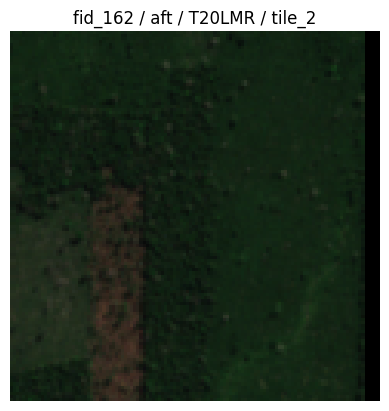

In [15]:
import rasterio, numpy as np, matplotlib.pyplot as plt

tif = "/share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_202/evt/20230719T142719_20230719T142939_T20LMR/tile_0.tif"

with rasterio.open(tif) as src:
    rgb = src.read([4, 3, 2]).astype("float32")   # B4=red, B3=green, B2=blue

rgb = np.clip(rgb / 3000, 0, 1).transpose(1, 2, 0)  # scale reflectance & to HxWxC
plt.imshow(rgb)
plt.title("fid_162 / aft / T20LMR / tile_2")
plt.axis("off")
plt.show()


## 6. Disk usage summary

In [13]:
def dir_size_gb(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / 1e9

print(f"{'Model':<10} {'Product':<10} {'Size (GB)':>10} {'Files':>8}")
print("-" * 44)
total_gb = 0
total_files = 0
for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        product_dir = os.path.join(cfg["dir"], product)
        if os.path.exists(product_dir):
            gb = dir_size_gb(product_dir)
            n_files = sum(len(downloaded[model][product][w]) for w in WINDOWS)
            total_gb += gb
            total_files += n_files
            print(f"{model:<10} {product:<10} {gb:>10.3f} {n_files:>8}")
        else:
            print(f"{model:<10} {product:<10} {'N/A':>10} {'N/A':>8}")
print("-" * 44)
print(f"{'TOTAL':<10} {'':<10} {total_gb:>10.3f} {total_files:>8}")


Model      Product     Size (GB)    Files
--------------------------------------------
CROMA      s2_l2a          2.653     1374
CROMA      s1_grd          3.632     1697
TerraFM    s2_l2a            N/A      N/A
TerraFM    s1_rtc            N/A      N/A
Clay       s2_l2a            N/A      N/A
Clay       s1_rtc            N/A      N/A
--------------------------------------------
TOTAL                      6.284     3071


## 7. Grid alignment artifact (per FID)

Same polygon, three tile sizes. The grid is anchored to the EPSG:3857 origin (multiples of `tile_size_m`), not the polygon. A polygon located near a 2240 m grid boundary can be split into 4 TerraFM tiles while landing inside a single CROMA or Clay tile.

FID 387: area 0.192 km², bbox = [-6971434.0, -965694.2, -6970670.5, -965101.5]


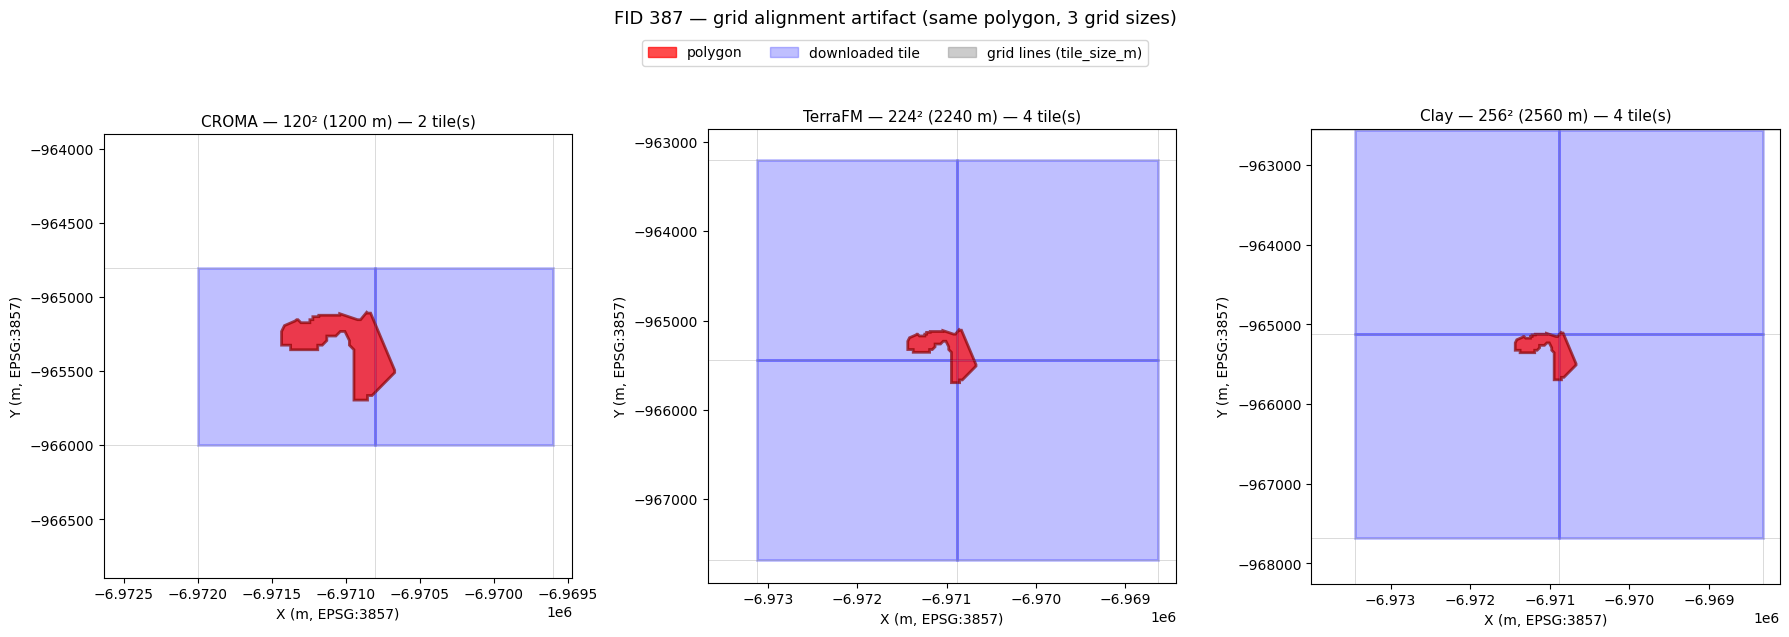


Tile counts on disk for FID 387:
Model      Product       evt    bef    aft   TOTAL
--------------------------------------------------
CROMA      s2_l2a          2      2      2       6
CROMA      s1_grd          2      2      2       6
TerraFM    s2_l2a          0      0      0       0
TerraFM    s1_rtc          0      0      0       0
Clay       s2_l2a          0      0      0       0
Clay       s1_rtc          0      0      0       0


In [14]:
import math
from shapely.geometry import box
import matplotlib.patches as mpatches

TARGET_FID = "387"

# ── Replicate create_tile_grid from tile_pipeline.py ──
def create_tile_grid(polygon_3857, tile_size_m):
    minx, miny, maxx, maxy = polygon_3857.bounds
    grid_minx = math.floor(minx / tile_size_m) * tile_size_m
    grid_miny = math.floor(miny / tile_size_m) * tile_size_m
    grid_maxx = math.ceil(maxx / tile_size_m) * tile_size_m
    grid_maxy = math.ceil(maxy / tile_size_m) * tile_size_m
    tiles = []
    x = grid_minx
    while x < grid_maxx:
        y = grid_miny
        while y < grid_maxy:
            t = box(x, y, x + tile_size_m, y + tile_size_m)
            if t.intersects(polygon_3857):
                tiles.append(t)
            y += tile_size_m
        x += tile_size_m
    return tiles


poly_row = _gdf[_gdf["fid"] == TARGET_FID]
if poly_row.empty:
    raise ValueError(f"FID {TARGET_FID} not in shapefile")
poly_3857 = poly_row.to_crs("EPSG:3857").geometry.iloc[0]
area_km2 = poly_3857.area / 1e6
print(f"FID {TARGET_FID}: area {area_km2:.3f} km², bbox = {[round(v, 1) for v in poly_3857.bounds]}")

# ── Visualization: 1×3, one model per panel ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (model, cfg) in zip(axes, TILE_SETS.items()):
    tile_size_m = cfg["size"] * 10
    tiles = create_tile_grid(poly_3857, tile_size_m)

    pminx, pminy, pmaxx, pmaxy = poly_3857.bounds
    ext_minx = pminx - tile_size_m
    ext_maxx = pmaxx + tile_size_m
    ext_miny = pminy - tile_size_m
    ext_maxy = pmaxy + tile_size_m

    gx = math.floor(ext_minx / tile_size_m) * tile_size_m
    while gx <= ext_maxx:
        ax.axvline(gx, color="gray", lw=0.5, alpha=0.4)
        gx += tile_size_m
    gy = math.floor(ext_miny / tile_size_m) * tile_size_m
    while gy <= ext_maxy:
        ax.axhline(gy, color="gray", lw=0.5, alpha=0.4)
        gy += tile_size_m

    for t in tiles:
        tx, ty = t.exterior.xy
        ax.fill(tx, ty, alpha=0.25, color="blue", edgecolor="blue", linewidth=2)

    geoms = [poly_3857] if poly_3857.geom_type == "Polygon" else list(poly_3857.geoms)
    for g in geoms:
        px, py = g.exterior.xy
        ax.fill(px, py, alpha=0.7, color="red", edgecolor="darkred", linewidth=2)

    ax.set_xlim(ext_minx, ext_maxx)
    ax.set_ylim(ext_miny, ext_maxy)
    ax.set_aspect("equal")
    ax.set_title(f"{model} — {cfg['size']}² ({tile_size_m} m) — {len(tiles)} tile(s)", fontsize=11)
    ax.set_xlabel("X (m, EPSG:3857)")
    ax.set_ylabel("Y (m, EPSG:3857)")

legend_handles = [
    mpatches.Patch(color="red", alpha=0.7, label="polygon"),
    mpatches.Patch(color="blue", alpha=0.25, label="downloaded tile"),
    mpatches.Patch(color="gray", alpha=0.4, label="grid lines (tile_size_m)"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
plt.suptitle(f"FID {TARGET_FID} — grid alignment artifact (same polygon, 3 grid sizes)",
             fontsize=13, y=1.06)
plt.tight_layout()
plt.show()


# ── Real on-disk tile counts for FID 101 ──
print(f"\nTile counts on disk for FID {TARGET_FID}:")
print(f"{'Model':<10} {'Product':<10} {'evt':>6} {'bef':>6} {'aft':>6} {'TOTAL':>7}")
print("-" * 50)
for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        counts = {}
        for window in WINDOWS:
            win_dir = os.path.join(cfg["dir"], product, f"fid_{TARGET_FID}", window)
            if not os.path.exists(win_dir):
                counts[window] = 0
                continue
            n_tiles_per_img = []
            for img in os.listdir(win_dir):
                full = os.path.join(win_dir, img)
                if os.path.isdir(full):
                    n_tiles_per_img.append(len(glob.glob(os.path.join(full, "tile_*.tif"))))
            counts[window] = max(n_tiles_per_img) if n_tiles_per_img else 0
        total = sum(counts.values())
        print(f"{model:<10} {product:<10} {counts['evt']:>6} {counts['bef']:>6} {counts['aft']:>6} {total:>7}")


# Longest time series

Longest time series per type of deforestation

In [15]:
# ── Paso A: parsear los CSVs para TODOS los FIDs (sin filtro de sample) ──
expected_all = defaultdict(lambda: defaultdict(lambda: defaultdict(set)))

for csv_name in CSV_FILES:
    version = csv_name.split("_")[0]  # v1, v2, v3
    csv_path = os.path.join(CSV_DIR, csv_name)
    if not os.path.exists(csv_path):
        print(f"WARNING: {csv_path} not found")
        continue
    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            fid = row["fid"].strip()
            if not fid:
                continue
            for (sensor, window), col in IMAGE_ID_COLUMNS.items():
                raw = row.get(col, "").strip()
                if not raw:
                    continue
                ids = [x.strip() for x in raw.split(",") if x.strip()]
                for img_id in ids:
                    expected_all[fid][(sensor, window)][img_id].add(version)

print(f"All FIDS IN THE CSV: {len(expected_all)}")

All FIDS IN THE CSV: 389


In [16]:
gdf_full = _gdf
# Type of deforestation for each fid
fid_to_type = dict(zip(gdf_full["fid"], gdf_full["CLASSNAME"]))

print(fid_to_type)

# Function to find the fids with the most images per type of deforestation, based on the CSV data (not disk)
def longest_series_per_type(expected_all, fid_to_type, top_n=2,
                              min_per_window=2, sensors=("s2",)):
      windows = ("bef", "evt", "aft")
  
      def passes_window_min(sw_dict):
          """True if EACH window has >= min_per_window images (for the given sensors)."""
          for win in windows:
              n = sum(len(sw_dict.get((s, win), {})) for s in sensors)
              if n < min_per_window:
                  return False
          return True 

      # Step C: fid -> total #images, ONLY for fids that pass the per-window minimum
      fid_to_count = {}
      for fid, sw_dict in expected_all.items():
          if not passes_window_min(sw_dict):
              continue                                  # drop fids with poor windows
          fid_to_count[fid] = sum(len(ids) for ids in sw_dict.values())

      # Step D: group fids by type 
      by_type = defaultdict(list)
      for fid, count in fid_to_count.items():
          ctype = fid_to_type.get(fid)
          if ctype is None:
              continue
          by_type[ctype].append((fid, count))

      # Step E: sort and keep top_n per type
      result = {}
      for ctype, fids in by_type.items():
          fids_sorted = sorted(fids, key=lambda x: (-x[1], int(x[0])))
          result[ctype] = fids_sorted[:top_n]
      return result 

{'1': 'Fire scar', '2': 'Disorderly Selective logging', '3': 'Disorderly Selective logging', '4': 'Clear-cut bare soil', '5': 'Clear-cut bare soil', '6': 'Clear-cut bare soil', '7': 'Fire scar', '8': 'Fire scar', '9': 'Clear-cut bare soil', '10': 'Fire scar', '11': 'Fire scar', '12': 'Fire scar', '13': 'Fire scar', '14': 'Fire scar', '15': 'Fire scar', '16': 'Fire scar', '17': 'Fire scar', '18': 'Fire scar', '19': 'Fire scar', '20': 'Clear-cut bare soil', '21': 'Fire scar', '22': 'Fire scar', '23': 'Degradation', '24': 'Degradation', '25': 'Fire scar', '26': 'Fire scar', '27': 'Fire scar', '28': 'Degradation', '29': 'Degradation', '30': 'Clear-cut bare soil', '31': 'Clear-cut bare soil', '32': 'Fire scar', '33': 'Clear-cut bare soil', '34': 'Clear-cut bare soil', '35': 'Clear-cut bare soil', '36': 'Clear-cut bare soil', '37': 'Degradation', '38': 'Clear-cut bare soil', '39': 'Clear-cut bare soil', '40': 'Fire scar', '41': 'Fire scar', '42': 'Clear-cut bare soil', '43': 'Degradation', '

In [25]:
top2 = longest_series_per_type(expected_all, fid_to_type, top_n=2)
print(top2)

top2_fids = [int(fid) for fids in top2.values() for fid, count in fids]
print(top2_fids)

{'Clear-cut bare soil': [('83', 74), ('380', 73)], 'Degradation': [('389', 47), ('359', 44)], 'Clear-cut vegetation': [('318', 35), ('236', 34)], 'Fire scar': [('11', 50), ('10', 49)], 'Disorderly Selective logging': [('371', 47), ('60', 46)], 'Geometric Selective logging': [('78', 56), ('384', 48)]}
[83, 380, 389, 359, 318, 236, 11, 10, 371, 60, 78, 384]


# Delete noisy image and duplicates

In [18]:
import os, glob, shutil
# 2023-09-07
# Code to find and delete the image 
date_token = "20230907"  # 2023-09-07

for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        pattern = os.path.join(cfg["dir"], product, "fid_*", "*", f"*{date_token}*")
        for img_path in glob.glob(pattern):
            if os.path.isdir(img_path):
                print("deleting", img_path)
                shutil.rmtree(img_path)


In [19]:
import os, glob, shutil
PRODUCT = "s2_l2a"   # only S2 uses the MGRS grid -> only place duplicates occur

def duplicates_check(delete_=False):
    to_delete = 0
    dup_fids = set()
    for model, cfg in TILE_SETS.items():
        product_dir = Path(cfg["dir"], PRODUCT)
        if not product_dir.exists():
            continue
        # each fid_*/<window>/ holds one folder per acquisition
        for window_dir in sorted(product_dir.glob("fid_*/*")):
            if not window_dir.is_dir():
                continue
            by_day = defaultdict(list)
            for leaf in sorted(window_dir.iterdir()):
                if leaf.is_dir():
                    day = leaf.name[:8]          # YYYYMMDD
                    by_day[day].append(leaf)
            for day, folders in by_day.items():
                for f in folders[1:]:            # keep the first, drop the rest
                    print(f"[{model}] {f.relative_to(cfg['dir'])}")
                    to_delete += 1
                    dup_fids.add(window_dir.parent.name.replace("fid_", ""))
                    if delete_:
                        shutil.rmtree(f) 

    print(f"\nFolders to delete: {to_delete}")
    print(f"Duplicate FIDs: {sorted(dup_fids)}")
    print(f"Total unique FIDs with duplicates: {len(dup_fids)}")

In [20]:
duplicates_check(delete_=False)


Folders to delete: 0
Duplicate FIDs: []
Total unique FIDs with duplicates: 0


In [21]:
dup_groups = []   # each: {fid, window, day, tiles: {code: image_id}}
for model, cfg in TILE_SETS.items():
      for window_dir in sorted(glob.glob(os.path.join(cfg["dir"], PRODUCT, "fid_*", "*"))):
          by_day = defaultdict(dict)
          for leaf in sorted(os.listdir(window_dir)):
              if os.path.isdir(os.path.join(window_dir, leaf)):
                  by_day[leaf[:8]][leaf.split("_")[-1]] = leaf   # {code: image_id}
          for day, tiles in by_day.items():
              if len(tiles) >= 2:
                  dup_groups.append({
                      "dir":    cfg["dir"],
                      "fid":    os.path.basename(os.path.dirname(window_dir)).replace("fid_", ""),
                      "window": os.path.basename(window_dir),
                      "day":    day,
                      "tiles":  tiles,
                  })


In [22]:
print(f"Duplicate groups: {len(dup_groups)}")

Duplicate groups: 0


In [23]:
import random, os
import matplotlib.pyplot as plt

g = random.choice(dup_groups) 
print(f"fid {g['fid']} | {g['window']} | day {g['day']}")

fig, axes = plt.subplots(1, len(g["tiles"]), figsize=(6 * len(g["tiles"]), 6))
for ax, (code, image_id) in zip(axes, sorted(g["tiles"].items())):
    tif = os.path.join(g["dir"], "s2_l2a", f"fid_{g['fid']}", g["window"], image_id, "tile_0.tif")
    plot_s2_rgb(tif, ax, f"{code}\n{image_id}", g["fid"])
plt.tight_layout()  
plt.show()


IndexError: Cannot choose from an empty sequence

In [ ]:
duplicates_check(delete_=True)

[CROMA] s2_l2a/fid_100/aft/20230604T142721_20230604T142716_T20LNR
[CROMA] s2_l2a/fid_100/aft/20230609T142719_20230609T142938_T20LNR
[CROMA] s2_l2a/fid_100/bef/20230405T142711_20230405T142712_T20LNR
[CROMA] s2_l2a/fid_100/bef/20230430T142719_20230430T142714_T20LNR
[CROMA] s2_l2a/fid_100/evt/20230515T142711_20230515T142713_T20LNR
[CROMA] s2_l2a/fid_107/aft/20230604T142721_20230604T142716_T20LNR
[CROMA] s2_l2a/fid_107/aft/20230609T142719_20230609T142938_T20LNR
[CROMA] s2_l2a/fid_107/aft/20230619T142719_20230619T142934_T20LNR
[CROMA] s2_l2a/fid_107/bef/20230115T142711_20230115T142817_T20LNR
[CROMA] s2_l2a/fid_107/bef/20230214T142711_20230214T143425_T20LNR
[CROMA] s2_l2a/fid_107/bef/20230301T142709_20230301T142737_T20LNR
[CROMA] s2_l2a/fid_107/bef/20230405T142711_20230405T142712_T20LNR
[CROMA] s2_l2a/fid_107/bef/20230430T142719_20230430T142714_T20LNR
[CROMA] s2_l2a/fid_107/bef/20230515T142711_20230515T142713_T20LNR
[CROMA] s2_l2a/fid_110/aft/20230609T142719_20230609T142938_T20LNR
[CROMA] s2

In [ ]:
duplicates_check(delete_=False)


Folders to delete: 0
Duplicate FIDs: []
Total unique FIDs with duplicates: 0
